## Kısmi En Küçük Kareler Regresyonu (PLS - Model)

*Burada yine hitters veri setini kullanacağız. Veri Ön İşleme, One - Hot encoding ve test - train ayrımlarınu aynı anda yapacağız.*

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict

In [2]:
hit = pd.read_csv("hitters.csv")
df = hit.copy()
df = df.dropna()
dms = pd.get_dummies(df[["League", "Division", "NewLeague"]])
dms = dms.astype(int)
y = df["Salary"]
X_ = df.drop(["Salary", "League", "Division", "NewLeague"], axis = 1).astype("float64")
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [3]:
from sklearn.cross_decomposition import PLSRegression, PLSSVD

In [4]:
pls_model = PLSRegression(n_components = 2).fit(X_train, y_train)

In [5]:
pls_model.coef_

array([[ 2.47335600e-01,  1.13030348e+00,  2.08295898e+00,
         1.58599864e+00,  1.20781837e+00,  1.91015780e+00,
         3.55673082e+00,  1.21724059e-02,  4.94616408e-02,
         2.58964530e-01,  9.96443520e-02,  9.25548551e-02,
         9.84366218e-02,  1.77753399e-01,  4.68377973e-02,
        -1.43965788e-01,  3.51398888e+01, -7.43195797e+01,
         2.93829559e+01]])

### Çok Önemli !!!

*Burada atlanılmaması gereken çok önemli ufak bir detay var. Yukarıda PLS modeli oluştururken bileşen sayısını 2 olarak girdik. Fakat modelin bileşen sayısı dikkat ederseniz değişken sayısı kadar. Bunun da çok mantıklı bir sebebi var: Biz 2 bileşeni parametre olarak girdiğimiz zaman model aslında o bütün değişkenleri farklı ağırlıklarla harmanlayarak 2 bileşen oluşturuyor. Fakat modelimiz orijinal veri setindeki değişken sayısını hafızasında tutmak zorundadır. Çünkü yeni veri girişi olduğu zaman bileşen sayısı kadar değil de değişken sayısı kadar gözlem değeri geliyor.*

*Örneğin 10 değişkenli veri seti ile 2 bileşenli model eğittiğimizi düşünelim. Yeni bir gözlem birimi(yeni satır) geldiği zaman 10 farklı gözlem değeri ile geliyor. Modelin bu yeni veriyi kabul edip hata vermemesi ve bizim  girdiğimiz 10 değeri o kendi yarattığı **2 bileşenli sisteme** dönüştürebilmesi için, her bir orijinal değişkenin katsayısını hafızasında tutmak zorundadır. Bu böyle olmazsa model yeni gelen veriden tahmin üretemez.*

*Şimdi yine modeli bileşen sayısını kendimiz belirlemeden yeniden oluşturalım. Model tuning aşamasında optimum bileşen tespiti için bu işlemi yapıyoruz:*

In [6]:
pls_model = PLSRegression().fit(X_train, y_train)

## Tahmin

In [7]:
pls_model.predict(X_train)[0:10]

array([344.91941493, 848.87070769, 692.93622642, 185.56577984,
       435.49196077, 987.49530026, 120.63097106, 289.9263406 ,
       663.41886918, 817.90486641])

*Validasyon işlemlerine girmeden standart train ve test hatalarını hesaplayalım:*

In [8]:
y_pred = pls_model.predict(X_train)

In [9]:
#train hatası

In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
print(np.sqrt(mean_squared_error(y_train, y_pred)))

310.1167593109696


In [12]:
#r2 değeri

In [13]:
r2_score(y_train, y_pred)

0.5140424486535482

In [14]:
#test hatası

In [15]:
y_pred = pls_model.predict(X_test)

In [16]:
print(np.sqrt(mean_squared_error(y_test, y_pred)))

398.09956327448526


## Model Tuning

In [17]:
from sklearn import model_selection
import matplotlib.pyplot as plt

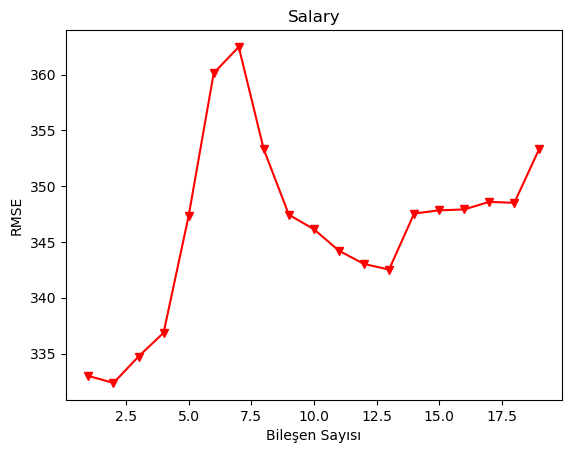

In [18]:
#Cross Validation
cv_10 = model_selection.KFold(n_splits = 10, shuffle = True, random_state = 1)

#Hata hesaplamak için döngü
RMSE = []
for i in np.arange(1, X_train.shape[1] + 1):
    pls = PLSRegression(n_components = i)
    score = np.sqrt(-1*model_selection.cross_val_score(pls,X_train,y_train.to_numpy().ravel(),cv = cv_10,scoring = "neg_mean_squared_error").mean())
    RMSE.append(score)

#Sonuçların Görselleştirilmesi
plt.plot(np.arange(1, X_train.shape[1] + 1), np.array(RMSE), '-v', c = 'r')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('RMSE')
plt.title('Salary');

*En başta bileşen sayısını 2 olarak girmiştik. Tesadüfi bir şekilde en optimum bileşen sayısı da 2.*

In [19]:
#final modelin oluşturulması

In [20]:
pls_model = PLSRegression(n_components = 2).fit(X_train, y_train)

In [21]:
#nihai test hatasının hesaplanması

In [22]:
y_pred = pls_model.predict(X_test)

In [23]:
print(np.sqrt(mean_squared_error(y_test, y_pred)))

398.09956327448526
